# Exploratory data and analysis and Preprocessing 

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

In [59]:
warnings.filterwarnings('ignore')

IMPORTING THE DATA

In [60]:
customer_info = pd.read_csv('customer_info.csv', index_col = False)

In [61]:
customer_info

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


In [62]:
print(customer_info.shape)

(33038, 25)


In [63]:
customer_basket = pd.read_csv('customer_basket.csv')
customer_basket

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


DATA CLEANING BEGINS

In [64]:
# I removed the Unnamed: 0 column because it functioned as a double index and wasn't necessary.
# Remove the 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in customer_info.columns:
    customer_info.drop(columns=['Unnamed: 0'], inplace=True)
customer_info

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


In [65]:
# Checking the data types of the columns in customer_info
customer_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  str    
 2   customer_gender                          33038 non-null  str    
 3   customer_birthdate                       32873 non-null  str    
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377 non-null  

In [66]:
# Checking the data_types of the columns in customer_basket
customer_basket.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   invoice_id     100000 non-null  int64
 1   list_of_goods  100000 non-null  str  
 2   customer_id    100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 14.7 MB


DEALING WITH MISSING VALUES

In [67]:
# Checking for missing values in customer_info
customer_info.isnull().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [68]:
# Checking for missing values in customer_basket
customer_basket.isnull().sum()

invoice_id       0
list_of_goods    0
customer_id      0
dtype: int64

In [69]:
# Since there are no missing values in customer_basket, then customer_info is the only one that needs to be cleaned.
# Checking the first few rows of customer_info
customer_info.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [70]:
# Checking the last few rows of customer_info
customer_info.tail()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235
33037,40000,Sammie Wright,female,07/09/1990 10:27 AM,0.0,1.0,1.0,1.0,4774.0,2127.0,...,729.0,1331.0,323.0,239.0,102.0,0.252563,2017.0,NaN,38.758936,-9.145988


In [71]:
# Create new column 'has_loyalty_card' based on presence of loyalty card number
customer_info['has_loyalty_card'] = customer_info['loyalty_card_number'].notna()

# Display the first few rows to verify the new column
customer_info[['loyalty_card_number', 'has_loyalty_card']].head()

,loyalty_card_number,has_loyalty_card
0,1.0,True
1,1.0,True
2,NaN,False
3,1.0,True
4,1.0,True


In [72]:
customer_info.drop(columns=['loyalty_card_number'], inplace=True)

The loyalty card number itself does not carry behavioural information. Therefore, it was transformed into a binary indicator identifying whether the customer participates in the loyalty program.

In [73]:
# First, convert customer_birthdate to datetime if not already done
customer_info['customer_birthdate'] = pd.to_datetime(customer_info['customer_birthdate'])

# Calculate age using today's date
from datetime import datetime
today = datetime.now()

# Calculate age using a more reliable method
customer_info['age'] = today.year - customer_info['customer_birthdate'].dt.year - (
    (today.month < customer_info['customer_birthdate'].dt.month) | 
    ((today.month == customer_info['customer_birthdate'].dt.month) & 
     (today.day < customer_info['customer_birthdate'].dt.day))
)

# Verify the new age column
print("\nAge statistics:")
print(customer_info['age'].describe())


Age statistics:
count    32873.000000
mean        54.553311
std         18.071943
min         24.000000
25%         39.000000
50%         54.000000
75%         70.000000
max         86.000000
Name: age, dtype: float64


In [74]:
# Get current columns as a list
cols = list(customer_info.columns)

# Remove 'age' from its current position and insert it after 'customer_birthdate'
cols.remove('age')
birthdate_index = cols.index('customer_birthdate')
cols.insert(birthdate_index + 1, 'age')

# Reorder the DataFrame columns
customer_info = customer_info[cols]

# Verify the new column order
print("New column order:")
print(customer_info.columns)

New column order:
Index(['customer_id', 'customer_name', 'customer_gender', 'customer_birthdate',
       'age', 'kids_home', 'teens_home', 'number_complaints',
       'distinct_stores_visited', 'lifetime_spend_groceries',
       'lifetime_spend_electronics', 'typical_hour',
       'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_videogames', 'lifetime_spend_petfood',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'latitude', 'longitude', 'has_loyalty_card'],
      dtype='str')


In [75]:
from sklearn.impute import SimpleImputer

numeric_cols = customer_info.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')

customer_info[numeric_cols] = imputer.fit_transform(customer_info[numeric_cols])

In [76]:
customer_info.isnull().sum().sum() #verifying that there are no 
# more missing values in customer_info


np.int64(165)

In [77]:
# which column is being stuborn? Let me guess... Age. 
customer_info[
    ['customer_id',
      'age',
     'kids_home',
     'teens_home',
     'number_complaints',
     'distinct_stores_visited']
].isnull().sum()

customer_id                0
age                        0
kids_home                  0
teens_home                 0
number_complaints          0
distinct_stores_visited    0
dtype: int64

In [78]:
# I was confused that age was not showing up as having missing values because I had 
# already imputed the missing values. But it had to be a column associated 
# with it.
customer_info.isnull().sum()


customer_id                                  0
customer_name                                0
customer_gender                              0
customer_birthdate                         165
age                                          0
kids_home                                    0
teens_home                                   0
number_complaints                            0
distinct_stores_visited                      0
lifetime_spend_groceries                     0
lifetime_spend_electronics                   0
typical_hour                                 0
lifetime_spend_vegetables                    0
lifetime_spend_nonalcohol_drinks             0
lifetime_spend_alcohol_drinks                0
lifetime_spend_meat                          0
lifetime_spend_fish                          0
lifetime_spend_hygiene                       0
lifetime_spend_videogames                    0
lifetime_spend_petfood                       0
lifetime_total_distinct_products             0
percentage_of

In [79]:
# it was birthdate so I decided to drop it completely. 
customer_info.drop(columns=['customer_birthdate'], inplace=True)

In [80]:
#Checking again for missing values
customer_info.isnull().sum()    

customer_id                                0
customer_name                              0
customer_gender                            0
age                                        0
kids_home                                  0
teens_home                                 0
number_complaints                          0
distinct_stores_visited                    0
lifetime_spend_groceries                   0
lifetime_spend_electronics                 0
typical_hour                               0
lifetime_spend_vegetables                  0
lifetime_spend_nonalcohol_drinks           0
lifetime_spend_alcohol_drinks              0
lifetime_spend_meat                        0
lifetime_spend_fish                        0
lifetime_spend_hygiene                     0
lifetime_spend_videogames                  0
lifetime_spend_petfood                     0
lifetime_total_distinct_products           0
percentage_of_products_bought_promotion    0
year_first_transaction                     0
latitude  

In [81]:
customer_info.isnull().sum().sum()

np.int64(0)

In [82]:
customer_info[['age']].dtypes

age    float64
dtype: object

In [83]:
print('age' in numeric_cols)

True


Missing values were handled through median imputation for numerical variables. Median imputation was preferred over mean imputation because spending-related variables exhibited skewed distributions and potential outliers.

In [84]:
customer_info.shape

(33038, 25)

In [85]:
customer_info["customer_name"] = customer_info["customer_name"].replace({"Phd.": " ", "Bsc.": " ", "Msc.": " "}, regex = True)

In [86]:
customer_info

,customer_id,customer_name,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,has_loyalty_card
0,3.0,Crystal Kitchens,female,56.0,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,38.794428,-9.215739,True
1,4.0,Glenda Bauman,female,50.0,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,38.751711,-9.179611,True
2,5.0,Antonio Campbell,male,54.0,0.0,0.0,1.0,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,38.780678,-9.160656,False
3,7.0,John Kelling,male,43.0,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,38.739548,-9.148679,True
4,8.0,Arthur Dematteo,male,56.0,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,38.733071,-9.188188,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996.0,Joshua Howard,male,53.0,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,38.742306,-9.163971,False
33034,39997.0,Anthony Hines,male,71.0,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,38.748505,-9.193445,False
33035,39998.0,Edna Hasselman,female,81.0,1.0,1.0,0.0,4.0,8029.0,1480.0,...,511.0,1719.0,89.0,258.0,206.0,0.181917,2012.0,38.776003,-9.137943,False
33036,39999.0,George Kramer,male,75.0,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,223.0,225.0,385.0,0.807259,2017.0,38.736034,-9.145235,False


In [87]:
customer_info

,customer_id,customer_name,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,has_loyalty_card
0,3.0,Crystal Kitchens,female,56.0,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,38.794428,-9.215739,True
1,4.0,Glenda Bauman,female,50.0,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,38.751711,-9.179611,True
2,5.0,Antonio Campbell,male,54.0,0.0,0.0,1.0,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,38.780678,-9.160656,False
3,7.0,John Kelling,male,43.0,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,38.739548,-9.148679,True
4,8.0,Arthur Dematteo,male,56.0,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,38.733071,-9.188188,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996.0,Joshua Howard,male,53.0,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,38.742306,-9.163971,False
33034,39997.0,Anthony Hines,male,71.0,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,38.748505,-9.193445,False
33035,39998.0,Edna Hasselman,female,81.0,1.0,1.0,0.0,4.0,8029.0,1480.0,...,511.0,1719.0,89.0,258.0,206.0,0.181917,2012.0,38.776003,-9.137943,False
33036,39999.0,George Kramer,male,75.0,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,223.0,225.0,385.0,0.807259,2017.0,38.736034,-9.145235,False


In [88]:
customer_info.columns.tolist()

['customer_id',
 'customer_name',
 'customer_gender',
 'age',
 'kids_home',
 'teens_home',
 'number_complaints',
 'distinct_stores_visited',
 'lifetime_spend_groceries',
 'lifetime_spend_electronics',
 'typical_hour',
 'lifetime_spend_vegetables',
 'lifetime_spend_nonalcohol_drinks',
 'lifetime_spend_alcohol_drinks',
 'lifetime_spend_meat',
 'lifetime_spend_fish',
 'lifetime_spend_hygiene',
 'lifetime_spend_videogames',
 'lifetime_spend_petfood',
 'lifetime_total_distinct_products',
 'percentage_of_products_bought_promotion',
 'year_first_transaction',
 'latitude',
 'longitude',
 'has_loyalty_card']

DEALING WITH OUTLIERS

In [89]:
# Checking for outliers in customer_info
customer_info.describe()

,customer_id,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,...,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude
count,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,...,33038.00000,33038.000000,33038.00000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000,33038.000000
mean,19974.265785,54.550548,1.114959,0.899903,0.932230,3.166263,16306.227798,2737.209093,12.646195,722.097464,...,723.82732,605.848205,819.00454,370.881803,336.032690,148.914644,0.318073,2015.311853,38.749694,-9.154549
std,11538.538632,18.026799,1.144485,0.958155,0.885716,1.665815,11985.903518,3423.263352,4.806783,649.043501,...,478.16681,489.840958,605.41894,456.638263,158.629151,105.922907,0.282328,5.032196,0.022498,0.028581
min,3.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,38.687987,-9.232989
25%,9985.250000,39.000000,0.000000,0.000000,0.000000,2.000000,8647.000000,592.000000,8.000000,228.250000,...,355.00000,180.000000,365.00000,126.000000,227.000000,67.000000,0.123383,2012.000000,38.734079,-9.173732
50%,19951.500000,54.000000,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,...,729.00000,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,38.748286,-9.156689
75%,29964.750000,70.000000,1.000000,1.000000,1.000000,4.000000,20807.000000,3674.000000,16.000000,1053.000000,...,1003.00000,907.000000,1114.00000,370.000000,432.000000,210.000000,0.465200,2019.000000,38.765779,-9.139608
max,40000.000000,86.000000,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,...,3052.00000,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,38.823693,-9.035697


In [90]:
# Get all numeric columns
numerical_columns = customer_info.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Remove columns we don't want
exclude_cols = ['customer_id', 'latitude', 'longitude']

numerical_columns = [
    col for col in numerical_columns
    if col not in exclude_cols
]

print(numerical_columns)

['age', 'kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'year_first_transaction']


In [91]:
# Detecting outliers
# Selecting all the numerical columns in customer_info for outlier detection
numerical_columns = customer_info.select_dtypes(include=['int64', 'float64']).columns
# Creating a function to detect outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound

In [92]:
# Detect and print outliers for each numerical column
for column in numerical_columns:
    outliers, lower_bound, upper_bound = detect_outliers(customer_info, column)
    print(f"\nOutliers in {column}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")


Outliers in customer_id:
Number of outliers: 0
Lower bound: -19984.00
Upper bound: 59934.00

Outliers in age:
Number of outliers: 0
Lower bound: -7.50
Upper bound: 116.50

Outliers in kids_home:
Number of outliers: 2579
Lower bound: -1.50
Upper bound: 2.50

Outliers in teens_home:
Number of outliers: 2098
Lower bound: -1.50
Upper bound: 2.50

Outliers in number_complaints:
Number of outliers: 1368
Lower bound: -1.50
Upper bound: 2.50

Outliers in distinct_stores_visited:
Number of outliers: 186
Lower bound: -1.00
Upper bound: 7.00

Outliers in lifetime_spend_groceries:
Number of outliers: 1836
Lower bound: -9593.00
Upper bound: 39047.00

Outliers in lifetime_spend_electronics:
Number of outliers: 2145
Lower bound: -4031.00
Upper bound: 8297.00

Outliers in typical_hour:
Number of outliers: 0
Lower bound: -4.00
Upper bound: 28.00

Outliers in lifetime_spend_vegetables:
Number of outliers: 446
Lower bound: -1008.88
Upper bound: 2290.12

Outliers in lifetime_spend_nonalcohol_drinks:
Numb

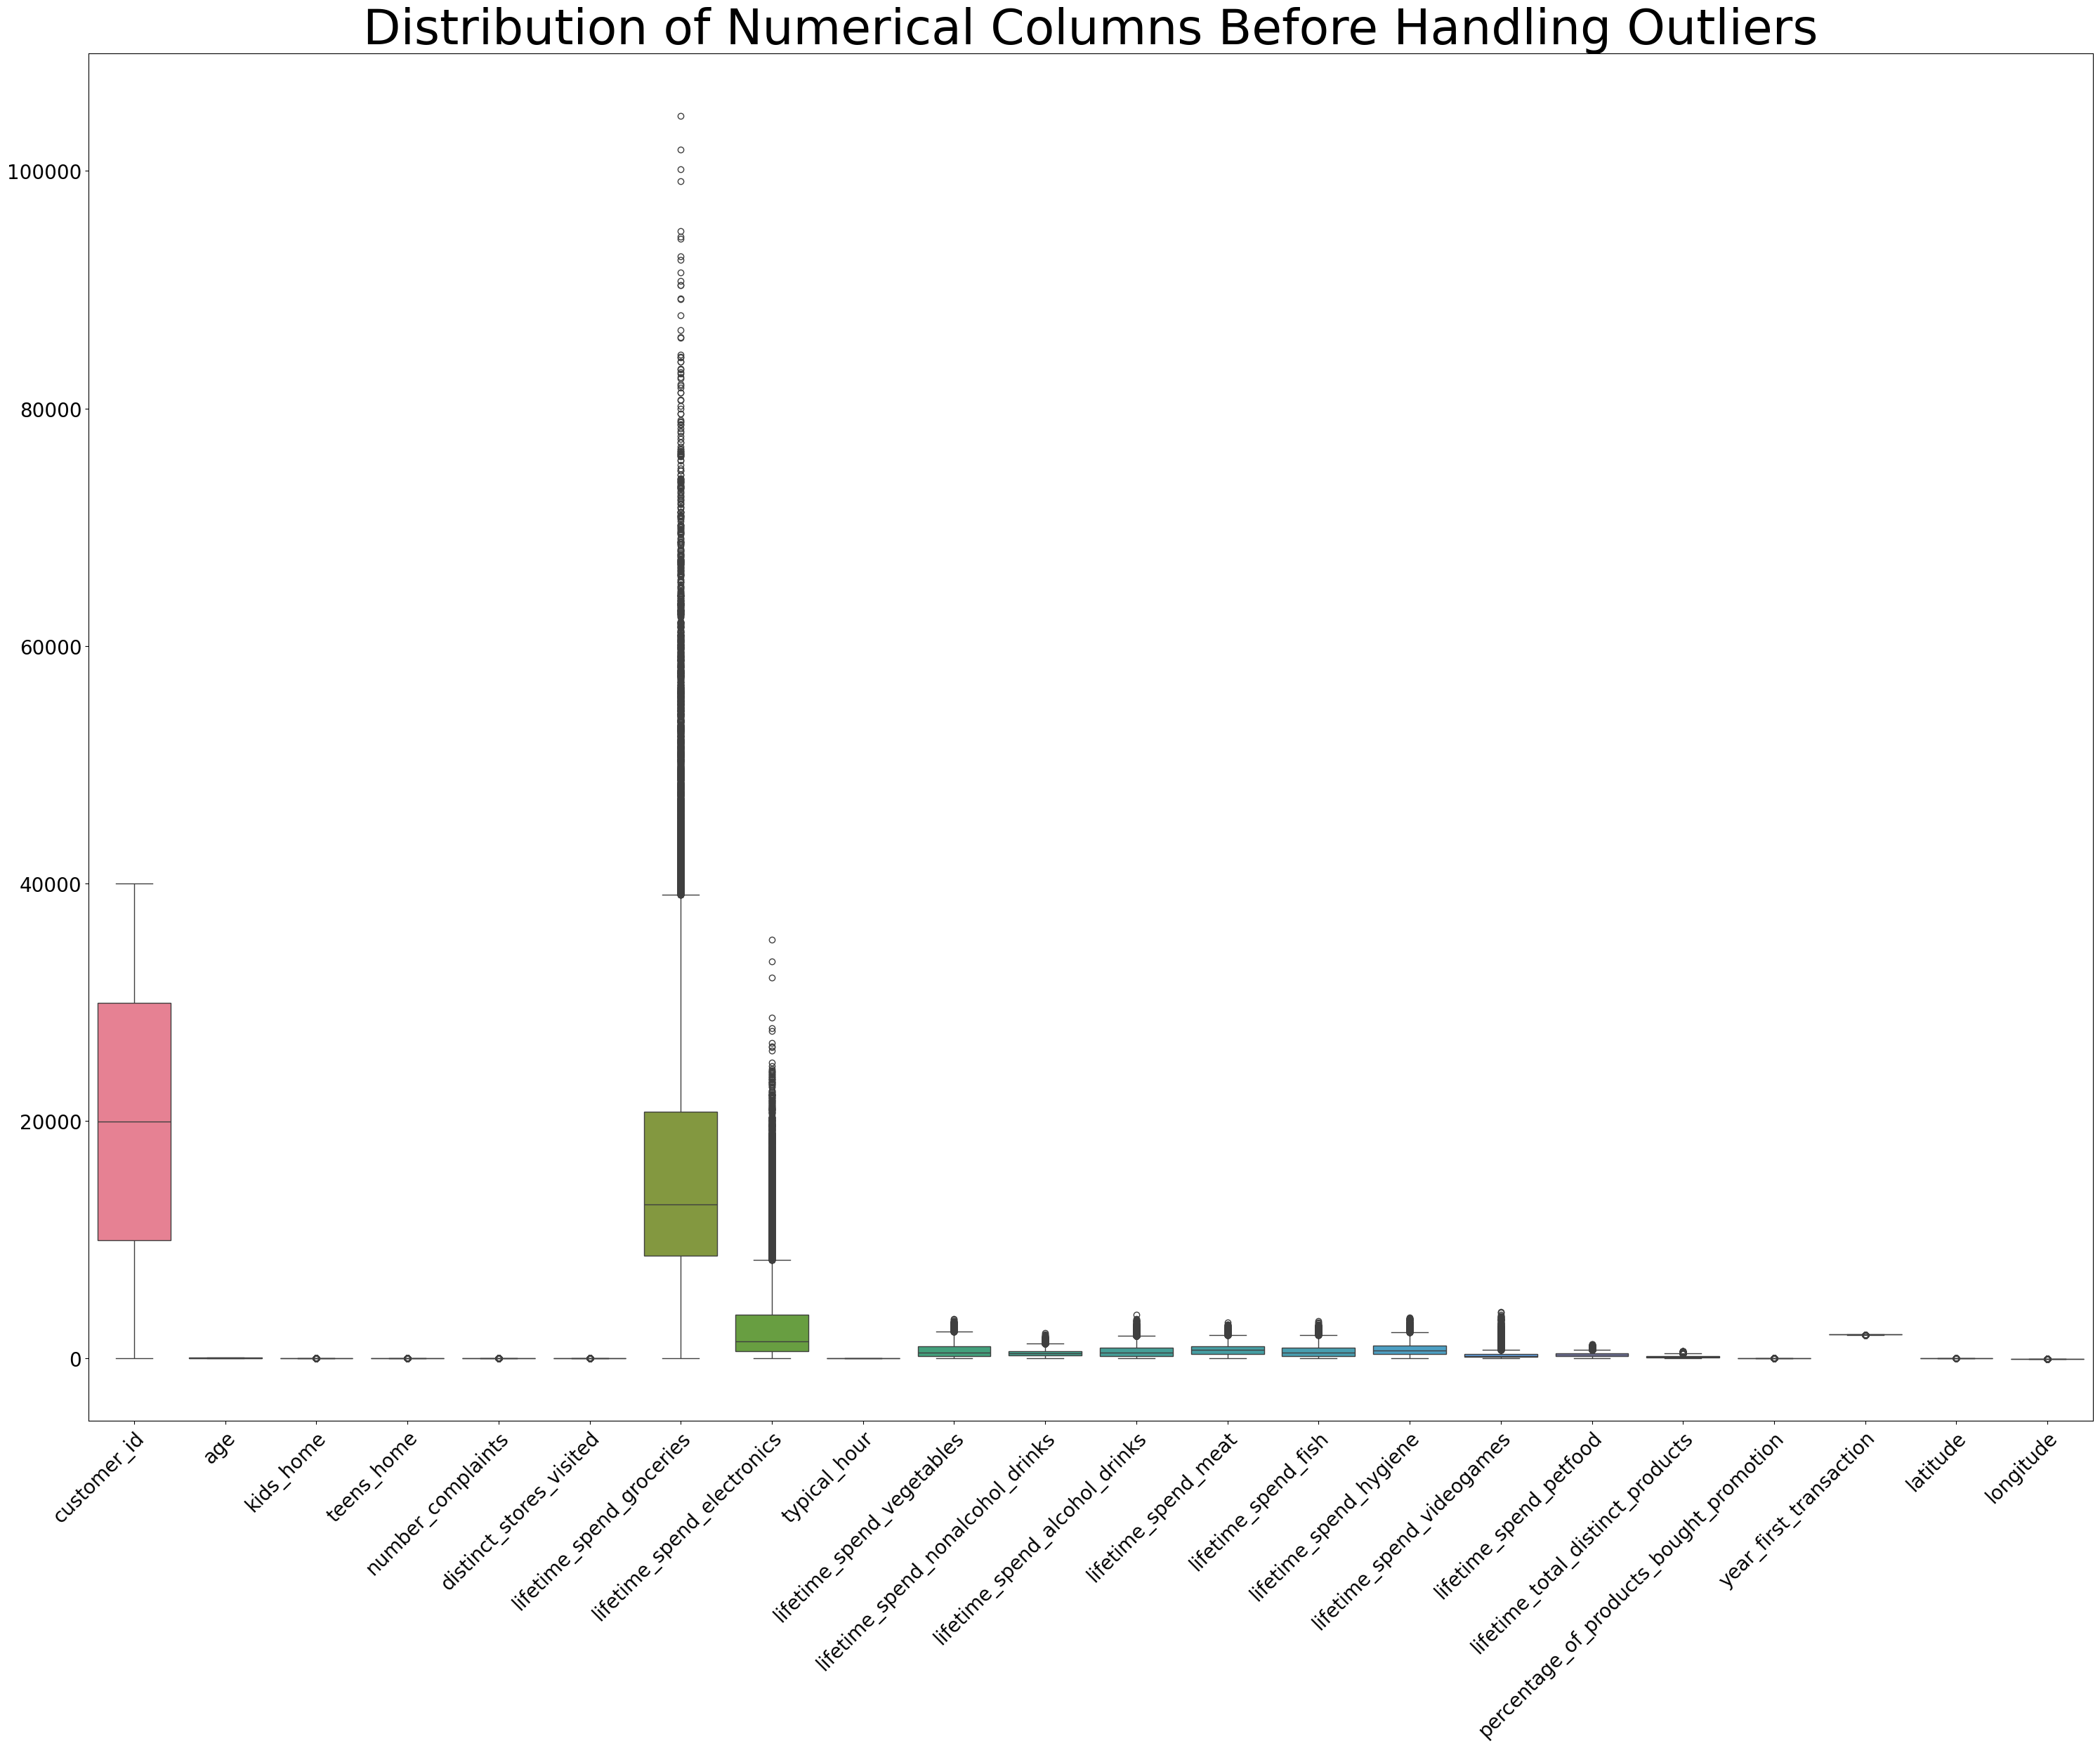

In [93]:
#Creating box plots before handling outliers to visualize the outliers
plt.figure(figsize=(30, 25))
sns.boxplot(data=customer_info[numerical_columns])
plt.xticks(rotation=45, fontsize =20, ha = "right", rotation_mode = "anchor")
plt.yticks(fontsize = 20)
plt.title("Distribution of Numerical Columns Before Handling Outliers", fontsize = 50)
plt.tight_layout()
plt.show()

In [94]:
# Handling outliers
# I decided to to use the IQR method as it is more robust when dealing with outliers.
# Creating a function to handle outliers by replacing them with the IQR
def handle_outliers(customer_info, columns):
    customer_info = customer_info.copy()
    for column in columns:
        Q1 = customer_info[column].quantile(0.25)
        Q3 = customer_info[column].quantile(.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        customer_info[column] = np.where(customer_info[column] < lower_bound, lower_bound, customer_info[column])
        customer_info[column] = np.where(customer_info[column] > upper_bound, upper_bound, customer_info[column])
    
    return customer_info

customer_info_clean = handle_outliers(customer_info, numerical_columns)

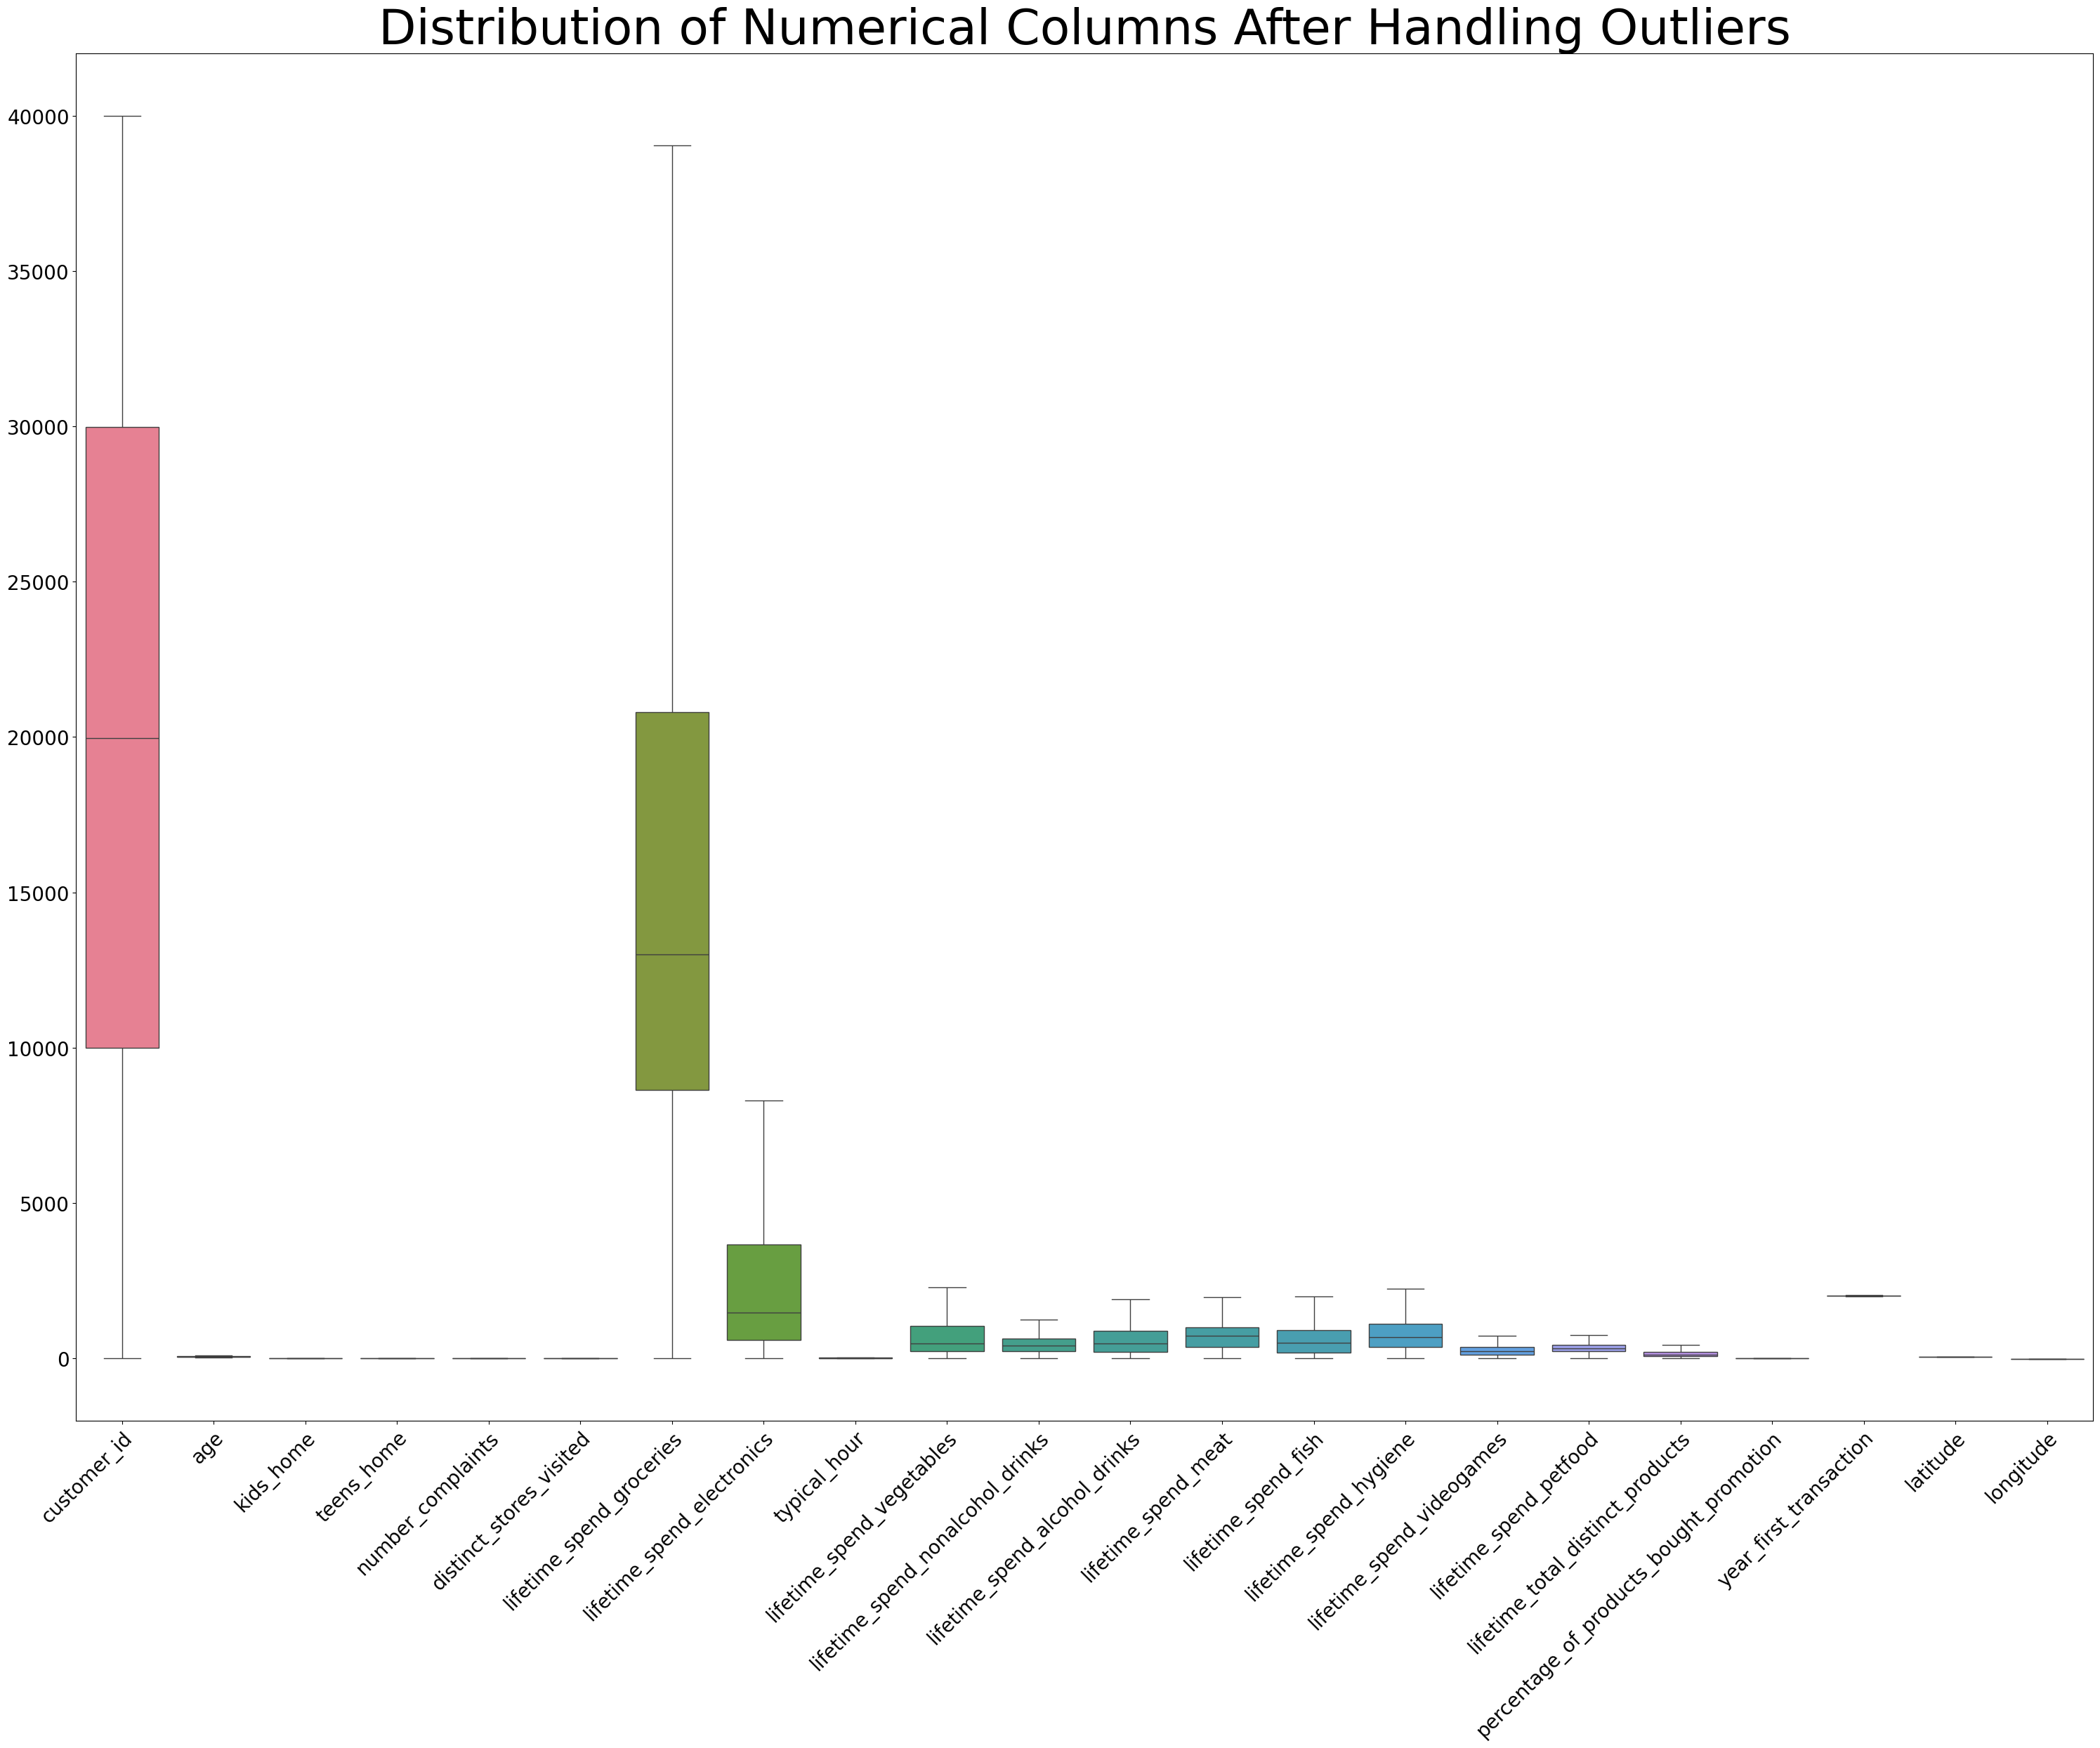

In [95]:
# Creating box plots after handling outliers to compare with the previous plots and check how the distribution changed
plt.figure(figsize=(30, 25))
sns.boxplot(data=customer_info_clean[numerical_columns])
plt.xticks(rotation=45, fontsize =20, ha = "right", rotation_mode = "anchor")
plt.yticks(fontsize = 20)
plt.title("Distribution of Numerical Columns After Handling Outliers", fontsize = 50)
plt.tight_layout()
plt.show()

In [96]:
'''# Change data types for selected columns
customer_info_clean = customer_info_clean.astype({
    "customer_id": "int64",
    "age": "int64",
    "kids_home": "int64",
    "teens_home": "int64",
    "number_complaints": "int64",
    "distinct_stores_visited": "int64",
})

# Verify the changes
print("Updated data types:")
print(customer_info_clean.dtypes)'''

# I was going to delete this but it helped me realise that there 
# were missing values in the age column since it kept throwing an 
# error when i tried converting the numerical columns frm float 
# to int (which I also realised wasn't necessary). 

'# Change data types for selected columns\ncustomer_info_clean = customer_info_clean.astype({\n    "customer_id": "int64",\n    "age": "int64",\n    "kids_home": "int64",\n    "teens_home": "int64",\n    "number_complaints": "int64",\n    "distinct_stores_visited": "int64",\n})\n\n# Verify the changes\nprint("Updated data types:")\nprint(customer_info_clean.dtypes)'

In [97]:
# customer_info_clean[
    # ['customer_id',
     # 'age',
     # 'kids_home',
     # 'teens_home',
     # 'number_complaints',
     # 'distinct_stores_visited']
# ].isnull().sum()
# discovered that age was the misbehaving column. 
'''customer_id                  0
age                        165
kids_home                    0
teens_home                   0
number_complaints            0
distinct_stores_visited      0
dtype: int64'''

'customer_id                  0\nage                        165\nkids_home                    0\nteens_home                   0\nnumber_complaints            0\ndistinct_stores_visited      0\ndtype: int64'

In [98]:
# Investigating
# customer_info_clean['age'].describe()
'''count    32873.000000
mean        54.550452
std         18.071978
min         24.000000
25%         39.000000
50%         54.000000
75%         70.000000
max         86.000000
Name: age, dtype: float64'''

'count    32873.000000\nmean        54.550452\nstd         18.071978\nmin         24.000000\n25%         39.000000\n50%         54.000000\n75%         70.000000\nmax         86.000000\nName: age, dtype: float64'

In [99]:
# customer_info_clean['age'].median()

In [100]:
# print("Shape:", customer_info_clean.shape)
# print("Total missing:", customer_info_clean.isnull().sum().sum())
# print("Missing age:", customer_info_clean['age'].isnull().sum())
'''Shape: (33038, 26)
Total missing: 330
Missing age: 165'''

'Shape: (33038, 26)\nTotal missing: 330\nMissing age: 165'

In [101]:
# customer_info_clean.isnull().sum().sort_values(ascending=False)
'''age_group                                  165
customer_birthdate                         165
age                                        165
lifetime_spend_meat                          0
has_loyalty_card                             0
longitude                                    0
latitude                                     0
year_first_transaction                       0
percentage_of_products_bought_promotion      0
lifetime_total_distinct_products             0
lifetime_spend_petfood                       0
lifetime_spend_videogames                    0
lifetime_spend_hygiene                       0
lifetime_spend_fish                          0
customer_id                                  0
lifetime_spend_alcohol_drinks                0
customer_name                                0
lifetime_spend_vegetables                    0
typical_hour                                 0
lifetime_spend_electronics                   0
lifetime_spend_groceries                     0
distinct_stores_visited                      0
number_complaints                            0
teens_home                                   0
kids_home                                    0
customer_gender                              0
lifetime_spend_nonalcohol_drinks             0
dtype: int64'''

'age_group                                  165\ncustomer_birthdate                         165\nage                                        165\nlifetime_spend_meat                          0\nhas_loyalty_card                             0\nlongitude                                    0\nlatitude                                     0\nyear_first_transaction                       0\npercentage_of_products_bought_promotion      0\nlifetime_total_distinct_products             0\nlifetime_spend_petfood                       0\nlifetime_spend_videogames                    0\nlifetime_spend_hygiene                       0\nlifetime_spend_fish                          0\ncustomer_id                                  0\nlifetime_spend_alcohol_drinks                0\ncustomer_name                                0\nlifetime_spend_vegetables                    0\ntypical_hour                                 0\nlifetime_spend_electronics                   0\nlifetime_spend_groceries               

In [102]:
# At this point, I came to the decision that creating age
# should be done before handling missing values. 

In [103]:
customer_info_clean

,customer_id,customer_name,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,has_loyalty_card
0,3.0,Crystal Kitchens,female,56.0,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,38.794428,-9.215739,True
1,4.0,Glenda Bauman,female,50.0,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,38.751711,-9.179611,True
2,5.0,Antonio Campbell,male,54.0,0.0,0.0,1.0,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,38.780678,-9.160656,False
3,7.0,John Kelling,male,43.0,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,736.0,184.0,92.0,0.253609,2021.0,38.739548,-9.148679,True
4,8.0,Arthur Dematteo,male,56.0,0.0,0.0,2.5,1.0,9187.0,8297.0,...,1015.0,297.0,736.0,441.0,6.0,0.186569,2021.0,38.733071,-9.188188,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996.0,Joshua Howard,male,53.0,0.0,0.0,2.0,1.0,475.0,8297.0,...,1154.0,62.0,736.0,366.0,162.0,0.261352,2014.0,38.742306,-9.163971,False
33034,39997.0,Anthony Hines,male,71.0,1.0,0.0,1.0,1.0,8430.0,8297.0,...,602.0,220.0,736.0,227.0,97.0,0.143479,2014.0,38.748505,-9.193445,False
33035,39998.0,Edna Hasselman,female,81.0,1.0,1.0,0.0,4.0,8029.0,1480.0,...,511.0,1719.0,89.0,258.0,206.0,0.181917,2012.0,38.776003,-9.137943,False
33036,39999.0,George Kramer,male,75.0,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,223.0,225.0,385.0,0.807259,2017.0,38.736034,-9.145235,False


In [104]:
customer_info_clean.isnull().sum()

customer_id                                0
customer_name                              0
customer_gender                            0
age                                        0
kids_home                                  0
teens_home                                 0
number_complaints                          0
distinct_stores_visited                    0
lifetime_spend_groceries                   0
lifetime_spend_electronics                 0
typical_hour                               0
lifetime_spend_vegetables                  0
lifetime_spend_nonalcohol_drinks           0
lifetime_spend_alcohol_drinks              0
lifetime_spend_meat                        0
lifetime_spend_fish                        0
lifetime_spend_hygiene                     0
lifetime_spend_videogames                  0
lifetime_spend_petfood                     0
lifetime_total_distinct_products           0
percentage_of_products_bought_promotion    0
year_first_transaction                     0
latitude  

DATA VISUALIZATION STARTS HERE

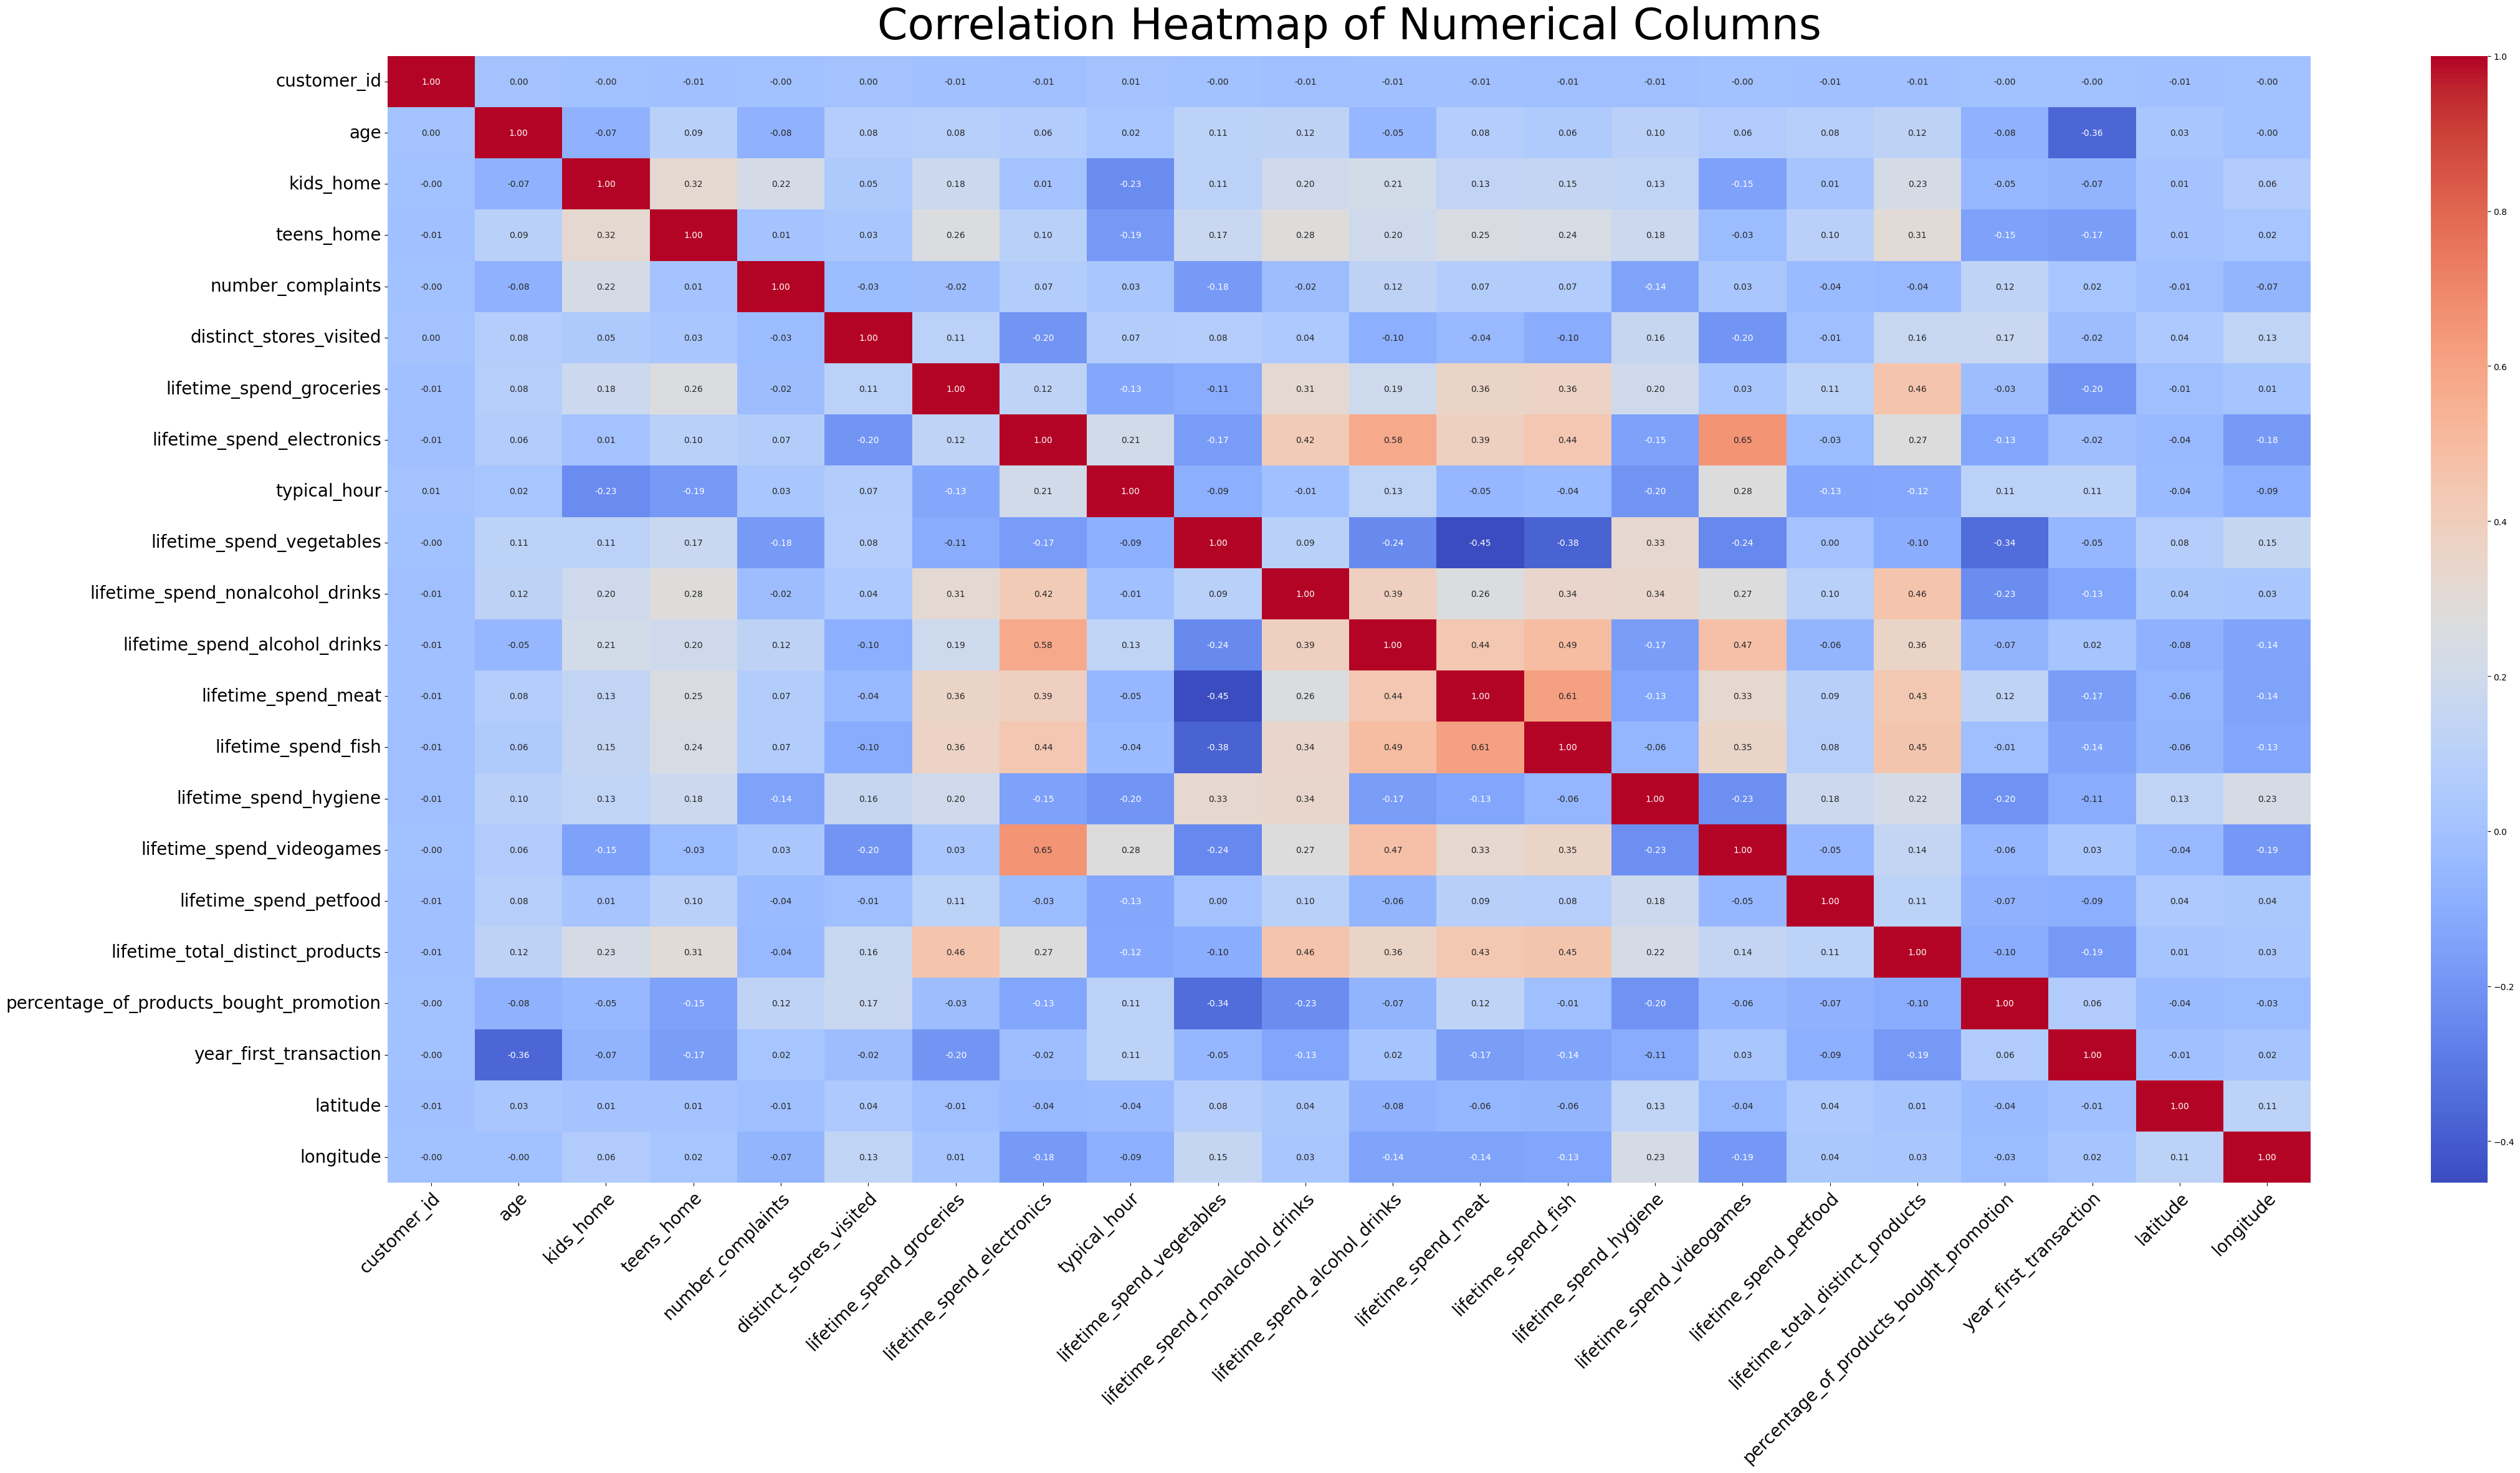

In [105]:
# Checking the correlation between numerical columns by plotting a correlation heatmap
plt.figure(figsize=(45, 25))

# Create heatmap with adjusted label parameters
sns.heatmap(customer_info_clean[numerical_columns].corr(), 
            annot=True, 
            fmt= ".2f", 
            cmap= "coolwarm", 
            cbar=True)

# Customize title
plt.title("Correlation Heatmap of Numerical Columns", fontsize=50, pad=20)

# Adjust x and y labels with better alignment
plt.xticks(rotation=45, fontsize=20, ha= "right", rotation_mode= "anchor")
plt.yticks(fontsize=20, va= "center")

# Adjust layout to prevent label cutoff
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

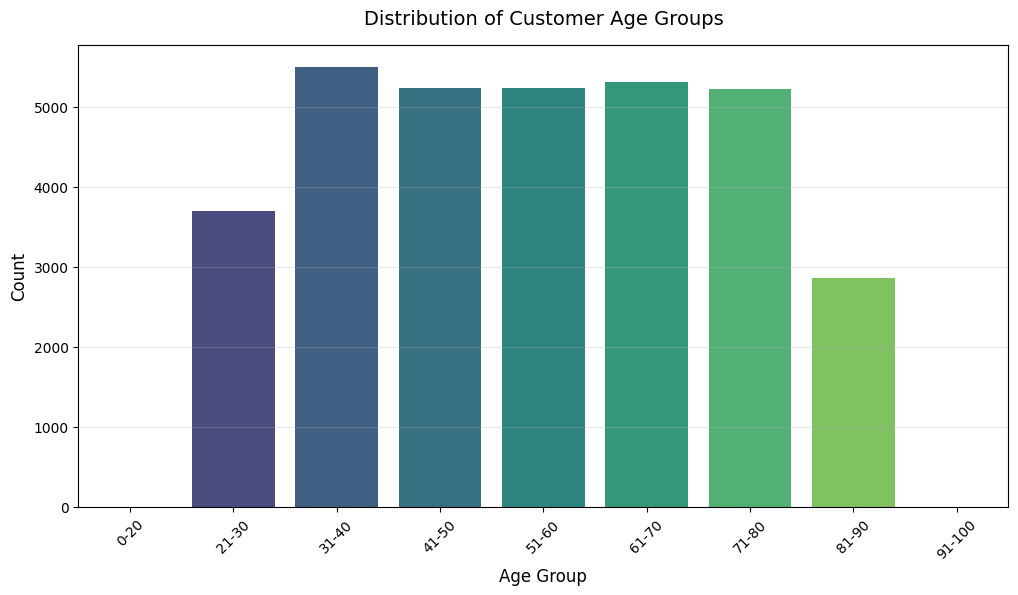

In [106]:
# Create age groups
bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ["0-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90", "91-100"]
customer_info_clean['age_group'] = pd.cut(customer_info_clean['age'], bins=bins, labels=labels)

# Create a bar plot of age groups
plt.figure(figsize=(12, 6))
sns.countplot(data=customer_info_clean, x= "age_group", palette= "viridis")

# Customize the plot
plt.title("Distribution of Customer Age Groups", fontsize=14, pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, alpha=0.3, axis="y")

# Show the plot
plt.show()

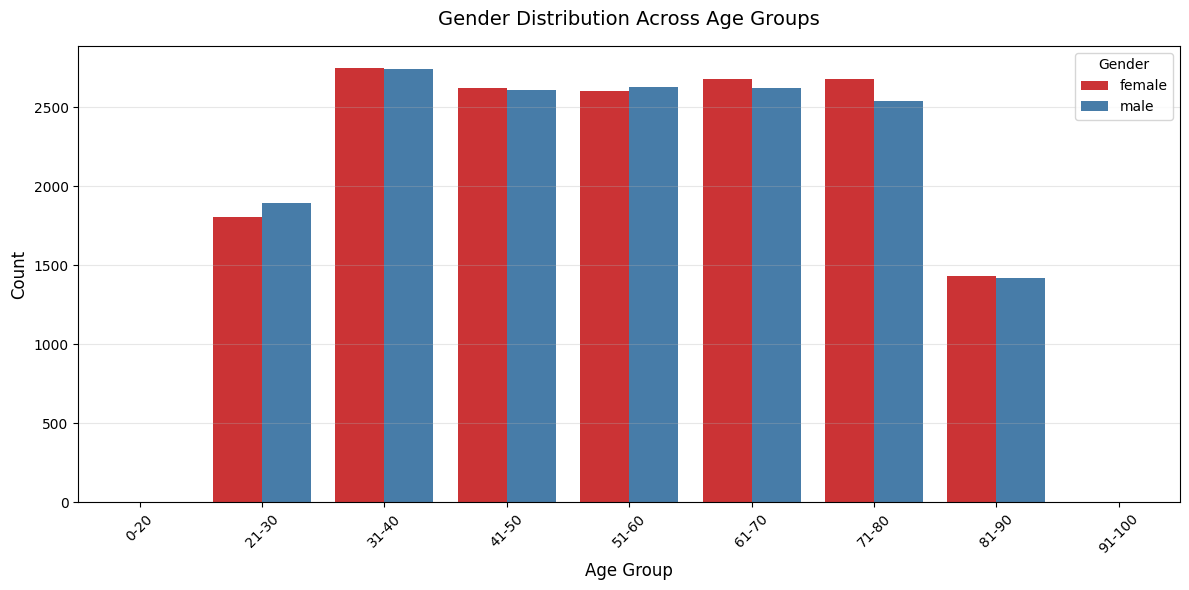

In [107]:
# Create a grouped bar chart for gender distribution by age group
plt.figure(figsize=(12, 6))
sns.countplot(data=customer_info_clean, 
              x= "age_group", 
              hue= "customer_gender",
              palette= "Set1")

# Customize the plot
plt.title("Gender Distribution Across Age Groups", fontsize=14, pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title= "Gender")

# Add grid for better readability
plt.grid(True, alpha=0.3, axis= "y")

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [108]:
customer_basket

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


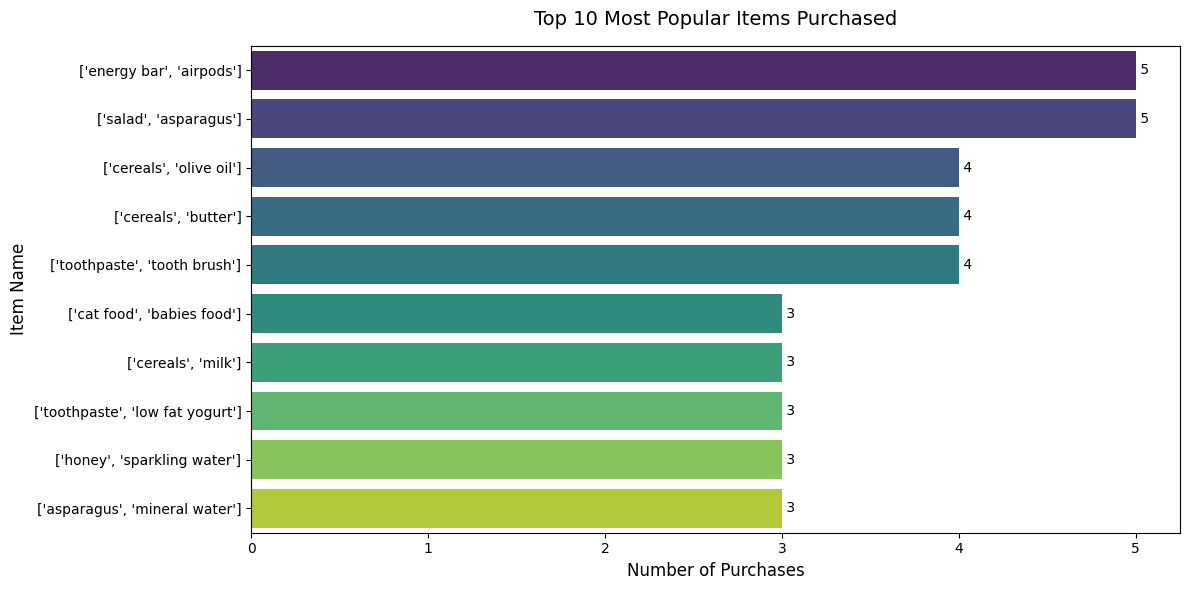

In [109]:
# Group by item and count occurrences
item_counts = customer_basket["list_of_goods"].value_counts().head(10)  # Get top 10 items

# Create a figure with larger size
plt.figure(figsize=(12, 6))

# Create bar plot
sns.barplot(x=item_counts.values, y=item_counts.index, palette= "viridis")

# Customize the plot
plt.title("Top 10 Most Popular Items Purchased", fontsize=14, pad=15)
plt.xlabel("Number of Purchases", fontsize=12)
plt.ylabel("Item Name", fontsize=12)

# Add value labels on the bars
for i, v in enumerate(item_counts.values):
    plt.text(v, i, f' {v:,}', va= "center", fontsize=10)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

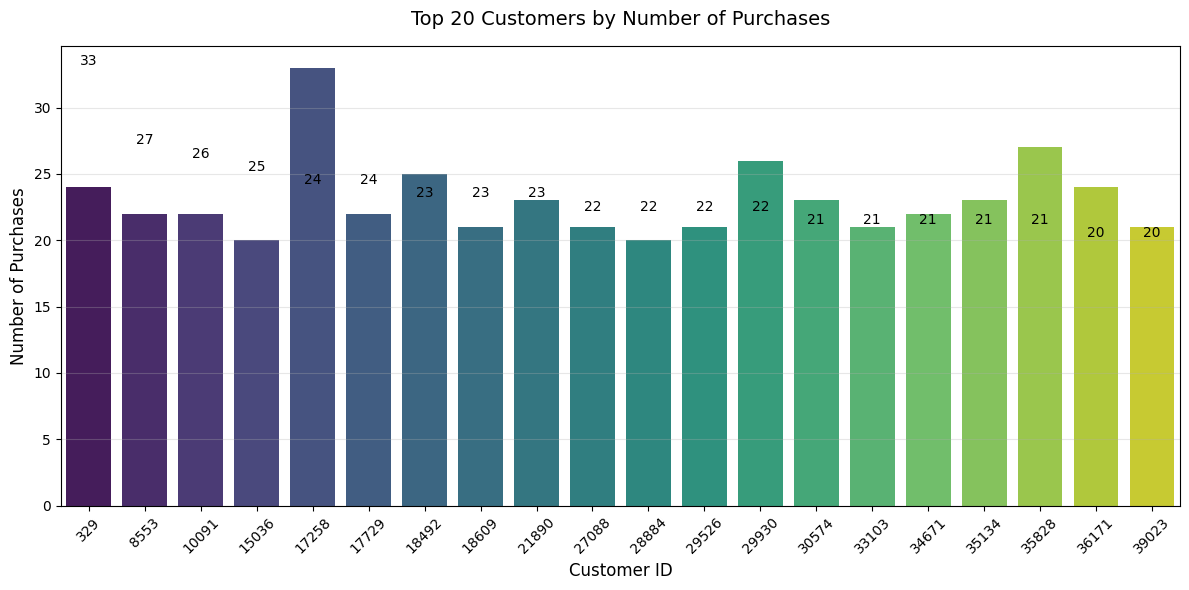

In [110]:
# Create a new cell to analyze purchases by customer
plt.figure(figsize=(12, 6))

# Group by customer_id and count their purchases
customer_purchases = customer_basket.groupby('customer_id')['list_of_goods'].count().sort_values(ascending=False)

# Plot top 20 customers for better visibility
top_customers = customer_purchases.head(20)

# Create bar plot
sns.barplot(x=top_customers.index, y=top_customers.values, palette='viridis')

# Customize the plot
plt.title('Top 20 Customers by Number of Purchases', fontsize=14, pad=15)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add value labels on the bars
for i, v in enumerate(top_customers.values):
    plt.text(i, v, f'{int(v)}', ha='center', va='bottom')

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

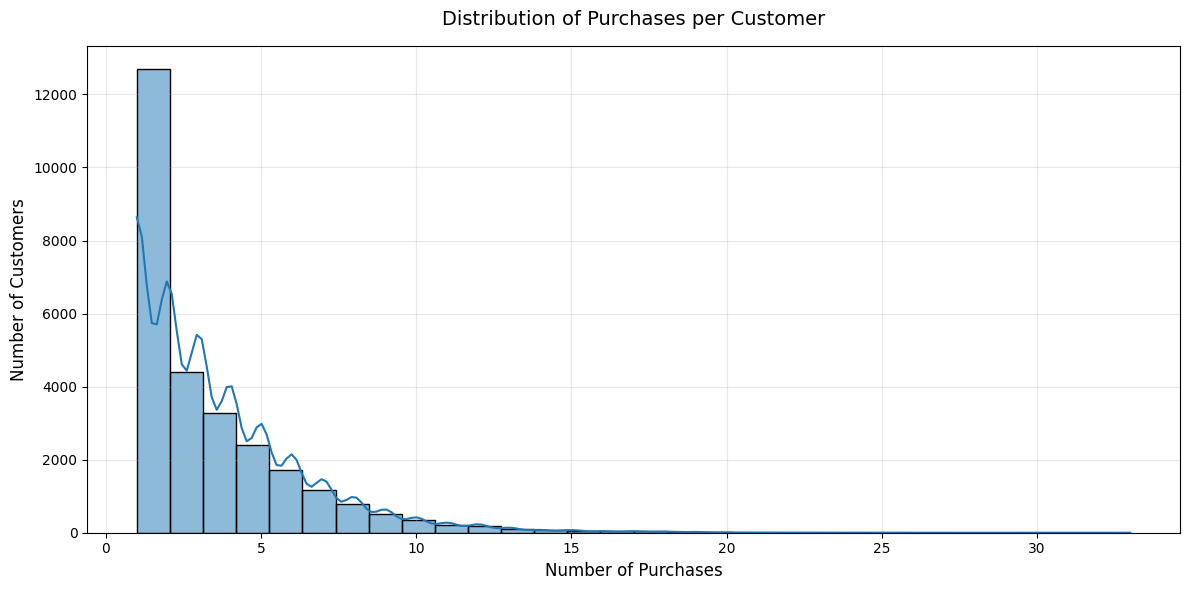

In [111]:
# Create a histogram of purchases per customer
plt.figure(figsize=(12, 6))

# Plot histogram
sns.histplot(data=customer_purchases, bins=30, kde=True)

# Customize the plot
plt.title('Distribution of Purchases per Customer', fontsize=14, pad=15)
plt.xlabel('Number of Purchases', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [112]:
customer_info.shape

(33038, 25)

In [113]:
customer_info_clean.to_csv("customer_info_clean.csv", index=False)